#  End-to-end retroseq preprocessing

1. Donor whitelist (20 mice).
2. Pre-QC: drop genes seen in <3 cells and cells with <200 detected genes (Seurat `CreateSeuratObject(min.cells=3, min.features=200)`).
3. QC subset: `2000 < n_genes_by_counts < 15000`, `pct_counts_mt < 10`, `pct_counts_ribo < 3`.
4. Low-resolution clustering → keep only the LC-NE / neuronal cluster (drops endothelial cluster).
5. Second-pass count floor: `n_genes_by_counts > 4000`.
6. Save filtered AnnData.

Inputs (produced by upstream capsule `LCNE_10X_preprocessing`):
- `genes.tsv`, `cells.tsv`, `metadata.csv`, `retro_raw.mtx`

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
from scipy.io import mmread

sys.path.append('/root/capsule/code/')
from utils import get_paths

sc.settings.verbosity = 1

## 1. Config / paths

In [ ]:
# Paths resolved via utils.get_paths() (reads config.toml). To point at a different
# data asset, update the prefix in config.toml — no change needed here.
paths = get_paths()
DATA_DIR = str(paths['retroseq_raw']) + '/'
OUT_PATH = str(paths['package_root'] / 'results' / 'retroseq' / 'retroseq_updated_filtered.h5ad')

# QC thresholds (match Polina's Rmd)
N_GENES_MIN, N_GENES_MAX = 2000, 15000
PCT_MT_MAX = 10
PCT_RIBO_MAX = 3
N_GENES_SECOND_PASS = 4000

# Pre-QC (mirrors Seurat CreateSeuratObject min.cells / min.features)
MIN_CELLS_PER_GENE = 3
MIN_GENES_PER_CELL = 200

# Clustering resolution for the non-neuronal-cluster removal step
LEIDEN_RES = 0.1

# Marker genes used to identify which leiden cluster is the LC-NE / neuronal cluster
NEURONAL_MARKERS = ['Dbh', 'Th', 'Slc6a2', 'Slc18a2']

## 2. Donor table
Hard-coded whitelist of 20 donors with injection target and sequencing run (from Polina's Rmd).
Living in this notebook for now; consider promoting to a committed `donors.csv` later.

In [ ]:
donors = pd.DataFrame({
    'external_donor_name': [
        '720570', '720571', '729424', '731339',
        '734350', '734351', '736527', '736528',
        '744523', '744524', '744526', '745034',
        '754294', '754295', '755030', '758591',
        '758586', '758590', '759651', '759654',
    ],
    'injection_site': [
        'frontal cortex', 'cerebellum',  'frontal cortex', 'cerebellum',
        'spinal cord',  'spinal cord',  'cerebellum',  'frontal cortex',
        'spinal cord',  'spinal cord',  'spinal cord',  'spinal cord',
        'spinal cord',  'spinal cord',  'thalamus',  'spinal cord',
        'thalamus',  'thalamus',  'thalamus',  'thalamus',
    ],
    'seq_run': [
        '1', '1', '2', '2',
        '2', '2', '3', '3',
        '3', '3', '3', '3',
        '4', '4', '4', '4',
        '4', '4', '4', '4',
    ],
})
donors

## 3. Load raw matrix

In [4]:
genes     = pd.read_csv(DATA_DIR + 'genes.tsv', header=None).values[:, 0]
cellnames = pd.read_csv(DATA_DIR + 'cells.tsv', header=None).values[:, 0]
metadata  = pd.read_csv(DATA_DIR + 'metadata.csv')
matrix    = mmread(DATA_DIR + 'retro_raw.mtx').tocsr()

print(f'Raw matrix: {matrix.shape[0]} cells x {matrix.shape[1]} genes')
print(f'metadata rows: {len(metadata)}')

Raw matrix: 1383 cells x 32245 genes
metadata rows: 1383


In [5]:
adata = ad.AnnData(X=matrix)
adata.var_names = genes
adata.obs = metadata.copy()
adata.obs_names = cellnames
adata.obs_names_make_unique()
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 1383 × 32245
    obs: 'Unnamed: 0', 'exp_component_name', 'ar_id', 'exp_component_vendor_name', 'batch', 'batch_vendor_name', 'tube', 'tube_internal_name', 'tube_contents_nm', 'tube_contents_nm_from_vendor', 'tube_avg_size_bp', 'tube_input_fmol', 'r1_index', 'r2_index', 'index_sequence_pair', 'organism', 'reference_id', 'facs_container', 'sample_name', 'patched_cell_container', 'cell_name', 'cell_id', 'studies', 'hemisphere_name', 'sample_quantity_count', 'sample_quantity_pg', 'external_donor_name', 'age', 'species', 'alignment_species', 'gender', 'control', 'cell_prep_type', 'full_genotype', 'facs_population_plan', 'cre_line', 'reporter', 'injection_roi', 'injection_method', 'injection_materials', 'propagation_type', 'roi', 'patchseq_roi', 'medical_conditions', 'slice_min_pos', 'slice_max_pos', 'rna_amplification_set', 'rna_amplification', 'method', 'amp_date', 'pcr_cycles', 'percent_cdna_longer_than_400bp', 'rna_amplification_pass_fail', 'amplifie

## 4. Pre-QC: gene/cell count floors (run on full matrix, Polina-style)
Mirrors `CreateSeuratObject(min.cells=3, min.features=200)` applied to the **full** count matrix
**before** the donor whitelist, so `n_genes_by_counts` is computed on the same gene set as Polina's pipeline.

In [6]:
n0 = adata.shape
sc.pp.filter_cells(adata, min_genes=MIN_GENES_PER_CELL)
sc.pp.filter_genes(adata, min_cells=MIN_CELLS_PER_GENE)
print(f'Before pre-QC: {n0}')
print(f'After  pre-QC: {adata.shape}')

Before pre-QC: (1383, 32245)
After  pre-QC: (1357, 24406)


## 5. Donor whitelist + attach injection target / seq run
Polina's Rmd: keep only cells from the 20 listed donors.

In [ ]:
adata.obs['external_donor_name'] = adata.obs['external_donor_name'].astype(str)
donors['external_donor_name']    = donors['external_donor_name'].astype(str)

in_whitelist = adata.obs['external_donor_name'].isin(donors['external_donor_name'])
print(f'Cells in donor whitelist: {in_whitelist.sum()} / {adata.n_obs}')

adata = adata[in_whitelist].copy()

# attach injection_site and seq_run
donor_map = donors.set_index('external_donor_name')
adata.obs['injection_site'] = adata.obs['external_donor_name'].map(donor_map['injection_site'])
adata.obs['seq_run']          = adata.obs['external_donor_name'].map(donor_map['seq_run'])

print(adata.obs['injection_site'].value_counts())
print(adata.obs['seq_run'].value_counts())

## 6. QC metrics

In [8]:
adata.var['mt']   = adata.var_names.str.startswith('mt-')
adata.var['ribo'] = adata.var_names.str.match(r'^Rp[ls]', case=False)  # Rps + Rpl, matches Polina's ^Rp[Ls]
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], inplace=True, log1p=True)

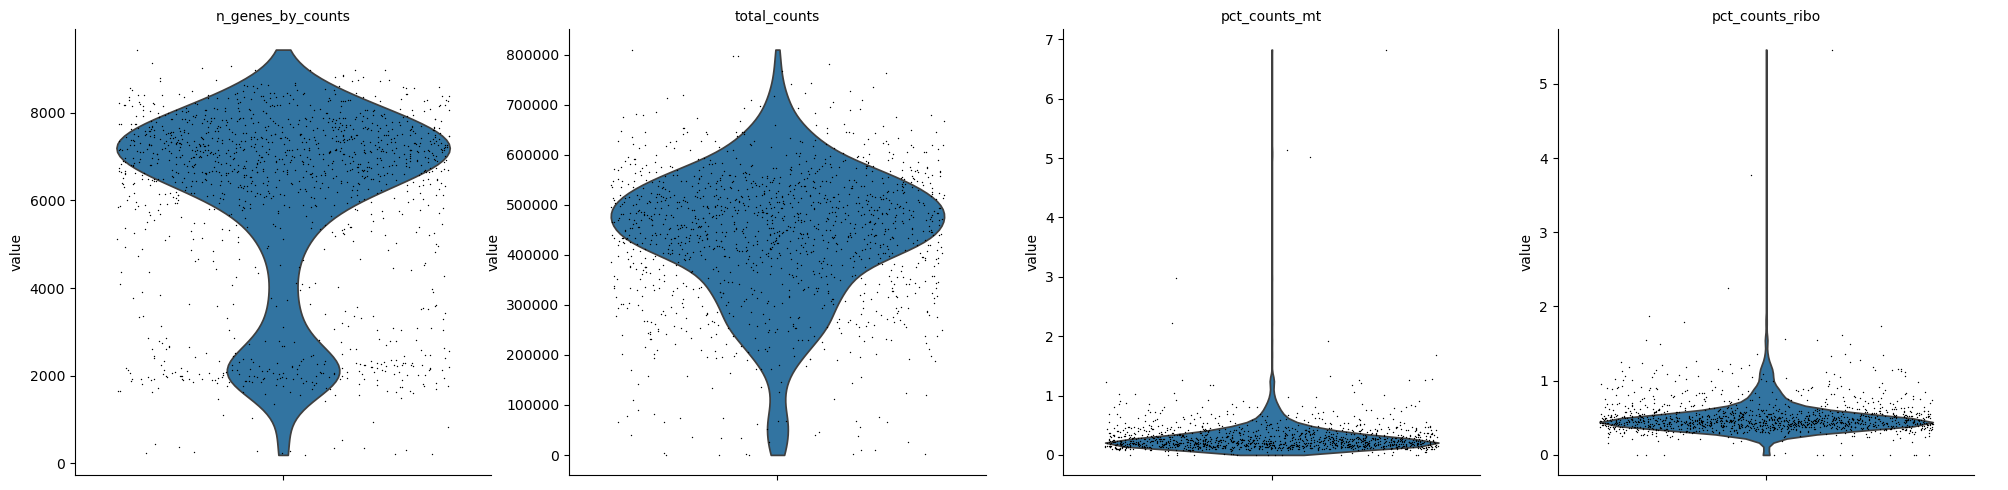

In [9]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'],
    jitter=0.4, multi_panel=True,
)

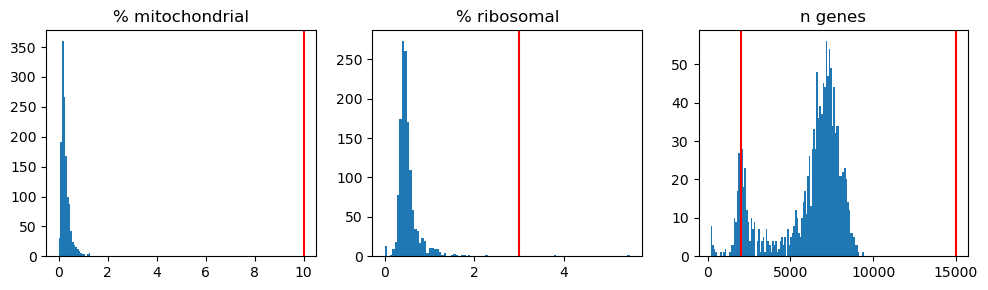

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].hist(adata.obs['pct_counts_mt'],   bins=100); axes[0].axvline(PCT_MT_MAX,   color='red'); axes[0].set_title('% mitochondrial')
axes[1].hist(adata.obs['pct_counts_ribo'], bins=100); axes[1].axvline(PCT_RIBO_MAX, color='red'); axes[1].set_title('% ribosomal')
axes[2].hist(adata.obs['n_genes_by_counts'], bins=100)
axes[2].axvline(N_GENES_MIN, color='red'); axes[2].axvline(N_GENES_MAX, color='red'); axes[2].set_title('n genes')
plt.tight_layout(); plt.show()

## 7. First QC subset (Polina's `subset(...)` call)

In [11]:
qc_mask = (
    adata.obs['n_genes_by_counts'].between(N_GENES_MIN, N_GENES_MAX)
    & (adata.obs['pct_counts_mt']   < PCT_MT_MAX)
    & (adata.obs['pct_counts_ribo'] < PCT_RIBO_MAX)
)
print(f'QC pass: {qc_mask.sum()} / {adata.n_obs}')
adata = adata[qc_mask].copy()
adata

QC pass: 1253 / 1357


AnnData object with n_obs × n_vars = 1253 × 24406
    obs: 'Unnamed: 0', 'exp_component_name', 'ar_id', 'exp_component_vendor_name', 'batch', 'batch_vendor_name', 'tube', 'tube_internal_name', 'tube_contents_nm', 'tube_contents_nm_from_vendor', 'tube_avg_size_bp', 'tube_input_fmol', 'r1_index', 'r2_index', 'index_sequence_pair', 'organism', 'reference_id', 'facs_container', 'sample_name', 'patched_cell_container', 'cell_name', 'cell_id', 'studies', 'hemisphere_name', 'sample_quantity_count', 'sample_quantity_pg', 'external_donor_name', 'age', 'species', 'alignment_species', 'gender', 'control', 'cell_prep_type', 'full_genotype', 'facs_population_plan', 'cre_line', 'reporter', 'injection_roi', 'injection_method', 'injection_materials', 'propagation_type', 'roi', 'patchseq_roi', 'medical_conditions', 'slice_min_pos', 'slice_max_pos', 'rna_amplification_set', 'rna_amplification', 'method', 'amp_date', 'pcr_cycles', 'percent_cdna_longer_than_400bp', 'rna_amplification_pass_fail', 'amplifie

## 8. Drop non-neuronal cluster
Polina clusters at `RNA_snn_res.0.1` (Seurat) and keeps cluster 0 (the neuronal one);
other clusters are endothelial. Reproduce in scanpy with leiden at the same low resolution
and identify the LC-NE cluster by mean expression of `Dbh / Th / Slc6a2 / Slc18a2`.

We do this on a **temporary** normalized/scaled copy so the saved AnnData keeps raw counts.

In [12]:
tmp = adata.copy()
tmp.layers['counts'] = tmp.X.copy()

sc.pp.normalize_total(tmp, target_sum=1e6)
sc.pp.log1p(tmp)
sc.pp.highly_variable_genes(tmp, n_top_genes=2000, flavor='seurat')
sc.pp.scale(tmp, max_value=10)
sc.tl.pca(tmp, n_comps=30)
sc.pp.neighbors(tmp, n_neighbors=20, n_pcs=10)  # Seurat FindNeighbors default k=20
sc.tl.leiden(tmp, resolution=LEIDEN_RES, key_added='leiden_lowres', random_state=0)
sc.tl.umap(tmp)

/opt/conda/lib/python3.12/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_19806/1991913505.py:10: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(tmp, resolution=LEIDEN_RES, key_added='leiden_lowres', random_state=0)


In [13]:
print(tmp.obs['leiden_lowres'].value_counts())

# Per-cluster mean of neuronal markers (on log-normalized data)
available_markers = [g for g in NEURONAL_MARKERS if g in tmp.var_names]
print('Markers present:', available_markers)

marker_idx = [tmp.var_names.get_loc(g) for g in available_markers]
X = tmp.X[:, marker_idx]
X = X.toarray() if hasattr(X, 'toarray') else np.asarray(X)
marker_df = pd.DataFrame(X, columns=available_markers, index=tmp.obs_names)
marker_df['leiden_lowres'] = tmp.obs['leiden_lowres'].values
cluster_means = marker_df.groupby('leiden_lowres').mean()
cluster_means['mean_marker'] = cluster_means.mean(axis=1)
cluster_means = cluster_means.sort_values('mean_marker', ascending=False)
cluster_means

leiden_lowres
0    1099
1     125
2      29
Name: count, dtype: int64
Markers present: ['Dbh', 'Th', 'Slc6a2', 'Slc18a2']


/tmp/ipykernel_19806/1365821337.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = marker_df.groupby('leiden_lowres').mean()


,Dbh,Th,Slc6a2,Slc18a2,mean_marker
leiden_lowres,,,,,
0,0.345963,0.344814,0.358471,0.361369,0.352654
2,-2.468919,-2.429078,-2.560674,-2.541901,-2.500143
1,-2.468919,-2.468060,-2.557599,-2.587439,-2.520504


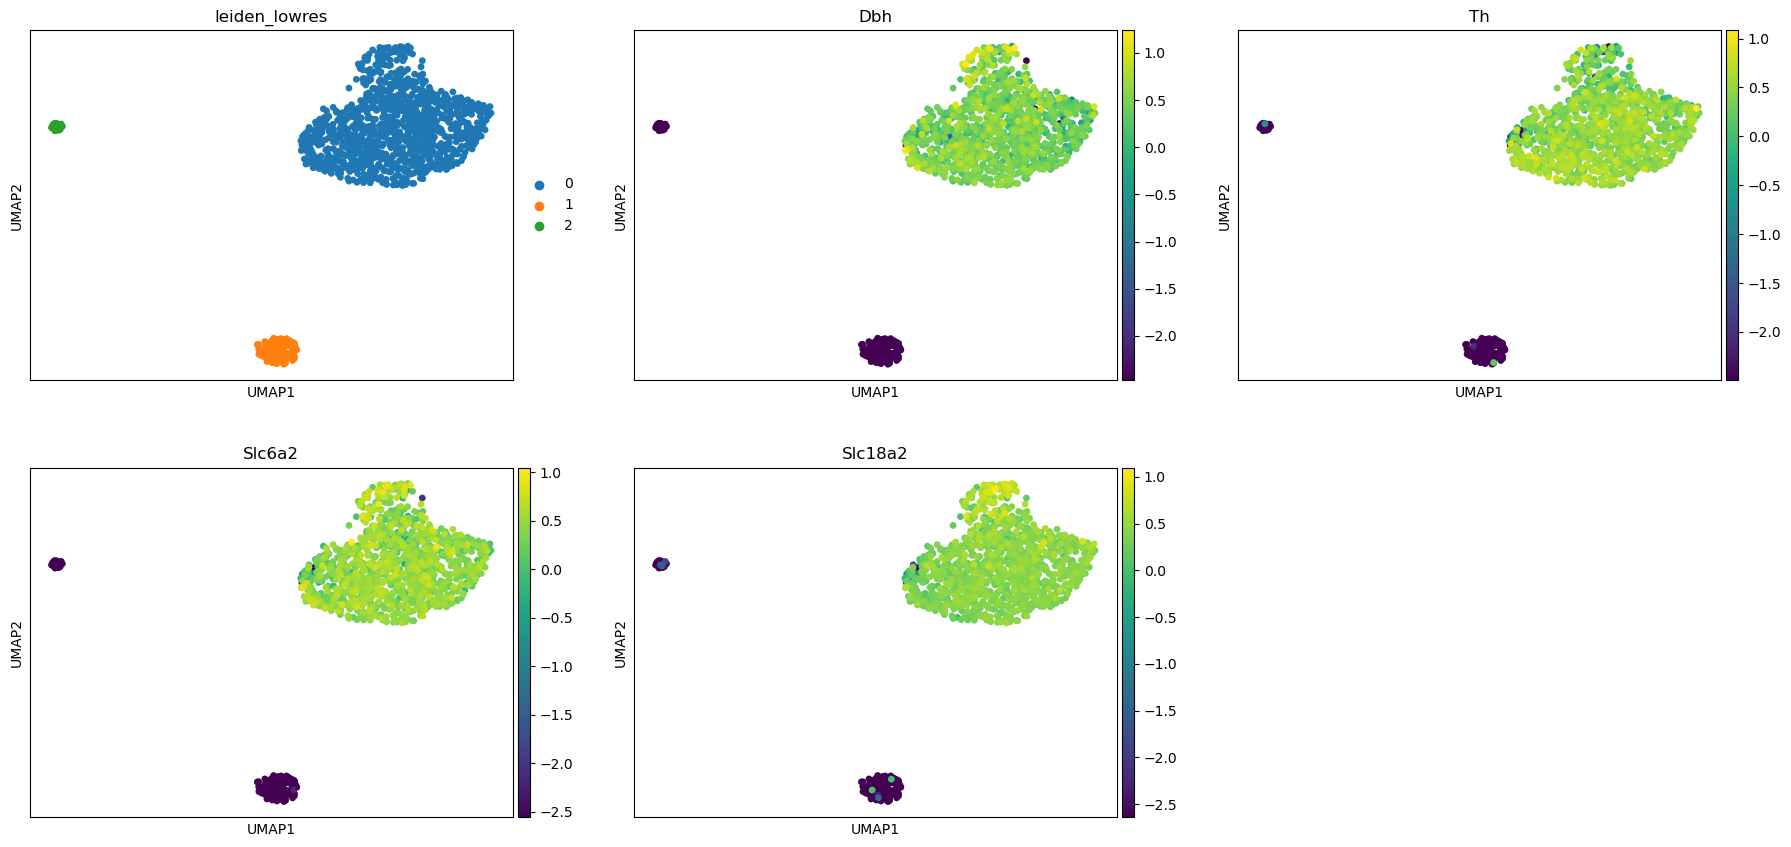

In [14]:
sc.pl.umap(tmp, color=['leiden_lowres'] + available_markers, ncols=3)

In [15]:
# Pick the cluster with the highest mean of the neuronal markers — this is the LC-NE cluster
neuronal_cluster = cluster_means.index[0]
print(f'Identified neuronal cluster: {neuronal_cluster!r}')
print(f'  cells in cluster: {(tmp.obs["leiden_lowres"] == neuronal_cluster).sum()}')

# Carry the cluster label back to the un-normalized adata, then subset
adata.obs['leiden_lowres'] = tmp.obs['leiden_lowres'].values
adata = adata[adata.obs['leiden_lowres'] == neuronal_cluster].copy()
adata

Identified neuronal cluster: '0'
  cells in cluster: 1099


AnnData object with n_obs × n_vars = 1099 × 24406
    obs: 'Unnamed: 0', 'exp_component_name', 'ar_id', 'exp_component_vendor_name', 'batch', 'batch_vendor_name', 'tube', 'tube_internal_name', 'tube_contents_nm', 'tube_contents_nm_from_vendor', 'tube_avg_size_bp', 'tube_input_fmol', 'r1_index', 'r2_index', 'index_sequence_pair', 'organism', 'reference_id', 'facs_container', 'sample_name', 'patched_cell_container', 'cell_name', 'cell_id', 'studies', 'hemisphere_name', 'sample_quantity_count', 'sample_quantity_pg', 'external_donor_name', 'age', 'species', 'alignment_species', 'gender', 'control', 'cell_prep_type', 'full_genotype', 'facs_population_plan', 'cre_line', 'reporter', 'injection_roi', 'injection_method', 'injection_materials', 'propagation_type', 'roi', 'patchseq_roi', 'medical_conditions', 'slice_min_pos', 'slice_max_pos', 'rna_amplification_set', 'rna_amplification', 'method', 'amp_date', 'pcr_cycles', 'percent_cdna_longer_than_400bp', 'rna_amplification_pass_fail', 'amplifie

## 9. Second-pass count floor (`n_genes_by_counts > 4000`)
Polina's tighter QC after picking the neuronal cluster, "to get more uniform sampling".

In [ ]:
before = adata.n_obs
adata = adata[adata.obs['n_genes_by_counts'] > N_GENES_SECOND_PASS].copy()
print(f'Second-pass nFeature > {N_GENES_SECOND_PASS}: {before} -> {adata.n_obs}')
print(adata.obs['injection_site'].value_counts())

## 10. Save filtered AnnData

In [ ]:
# stringify any object/categorical columns that scanpy/h5ad dislikes
for col in ['external_donor_name', 'seq_run', 'injection_site', 'leiden_lowres']:
    if col in adata.obs.columns:
        adata.obs[col] = adata.obs[col].astype(str)

os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
adata.write_h5ad(OUT_PATH)
print(f'Saved {adata.n_obs} cells x {adata.n_vars} genes to {OUT_PATH}')